# 03 — Hypothesis Tests

Five tests that determine whether the momentum strategy is worth trading.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats

from src.data import load_prices, compute_returns
from src.signals import load_signals
from src.hypothesis_tests import (
    compute_me_forward_returns,
    run_all_tests, _metrics,
)

plt.rcParams.update({'figure.dpi': 120})

PROC = '../data/processed'
prices  = load_prices(PROC)
returns = compute_returns(prices)
signals = load_signals(PROC)
fwd     = compute_me_forward_returns(prices)

print('Running all tests...')
R = run_all_tests(prices, returns, signals)

Running all tests...

  MOMENTUM STRATEGY — HYPOTHESIS TESTS

─────────────────────────────────────────────
Test 1 — Information Coefficient
─────────────────────────────────────────────
  Mean IC  : 0.0723
  IC Std   : 0.4093
  t-stat   : 2.765  (p=0.0061)
  IC > 0   : 55.1%
  N obs    : 245

  Annual IC:
2006    0.1396
2007    0.0691
2008    0.1397
2009    0.0244
2010    0.1555
2011    0.0652
2012   -0.0333
2013    0.2199
2014    0.1976
2015    0.1741
2016   -0.2012
2017    0.2229
2018   -0.0664
2019   -0.0226
2020    0.0988
2021    0.0994
2022    0.0211
2023   -0.0089
2024    0.0920
2025    0.1545
2026   -0.1564

─────────────────────────────────────────────
Test 2 — Top vs Bottom (N=4 each)
─────────────────────────────────────────────


                  Top   Bottom   Spread
Ann Return %    9.650   -1.260   10.920
Ann Vol %      16.030   16.760   20.440
Sharpe          0.602   -0.075    0.534
Max DD %      -38.600  -75.890  -37.800
Calmar          0.250   -0.017    0.289
N months      258.000  258.000  258.000

  H0: spread=0  →  t=2.476, p=0.0139

─────────────────────────────────────────────
Test 3 — Trend Filter
─────────────────────────────────────────────
              No filter  200DMA filter
Ann Return %      9.650          9.670
Ann Vol %        16.030         15.460
Sharpe            0.602          0.625
Max DD %        -38.600        -30.180
Calmar            0.250          0.320
N months        258.000        258.000

  Crisis total returns (%):
        No filter  200DMA filter
GFC        -11.81           3.28
COVID        4.91           4.91
2022BB      16.27          -5.22



─────────────────────────────────────────────
Test 4 — Portfolio Construction
─────────────────────────────────────────────
                equal  inv_vol  risk_parity      hrp
Ann Return %    9.670   10.650       10.850   10.320
Ann Vol %      15.460   12.490       12.510   11.650
Sharpe          0.625    0.853        0.867    0.886
Max DD %      -30.180  -24.210      -22.580  -19.860
Calmar          0.320    0.440        0.481    0.520
N months      258.000  258.000      258.000  258.000

─────────────────────────────────────────────
Test 5 — Cost Sensitivity
─────────────────────────────────────────────
                  5bp     10bp     25bp     50bp
Ann Return %    9.530    9.400    9.010    8.350
Ann Vol %      15.460   15.460   15.460   15.470
Sharpe          0.617    0.608    0.583    0.540
Max DD %      -30.360  -30.540  -31.060  -31.930
Calmar          0.314    0.308    0.290    0.262
N months      258.000  258.000  258.000  258.000

  Avg monthly one-way turnover : 21.9%
  

---
## Test 1 — Information Coefficient
*Does today's momentum ranking predict next month's return?*

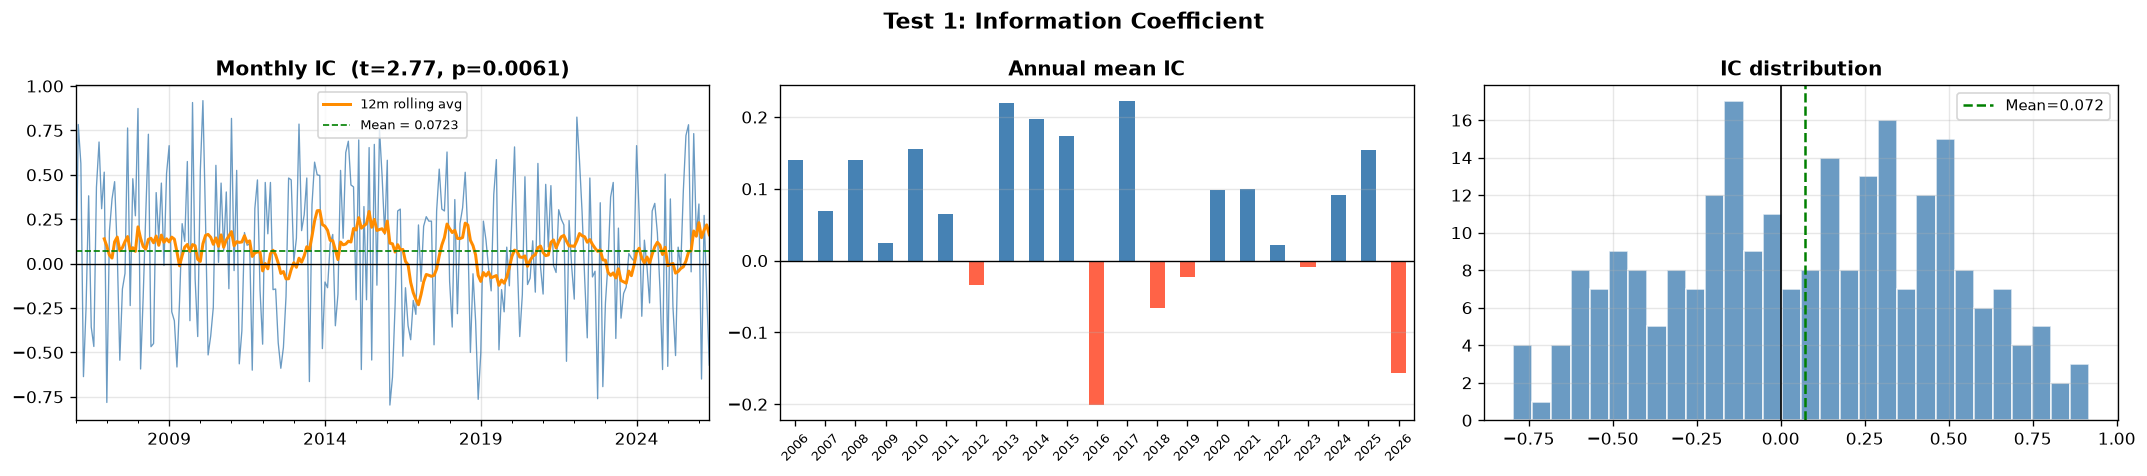

Verdict: Mean IC=0.0723, t=2.77, p=0.0061, IC>0 in 55.1% of months


In [2]:
ic   = R['t1_ic']['ic_series']
ann  = R['t1_ic']['annual_ic']
mean_ic = R['t1_ic']['mean_ic']
t    = R['t1_ic']['t_stat']
p    = R['t1_ic']['p_value']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# IC time series
ax = axes[0]
ic.plot(ax=ax, color='steelblue', linewidth=0.8, alpha=0.8)
ic.rolling(12).mean().plot(ax=ax, color='darkorange', linewidth=1.8, label='12m rolling avg')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(mean_ic, color='green', linewidth=1, linestyle='--', label=f'Mean = {mean_ic:.4f}')
ax.set_title(f'Monthly IC  (t={t:.2f}, p={p:.4f})', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Annual IC bar chart
ax = axes[1]
colors = ['steelblue' if v >= 0 else 'tomato' for v in ann]
ann.plot.bar(ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Annual mean IC', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(True, axis='y', alpha=0.3)

# IC distribution
ax = axes[2]
ax.hist(ic.dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(mean_ic, color='green', linewidth=1.5, linestyle='--', label=f'Mean={mean_ic:.3f}')
ax.set_title('IC distribution', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Test 1: Information Coefficient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Verdict: Mean IC={mean_ic:.4f}, t={t:.2f}, p={p:.4f}, IC>0 in {(ic>0).mean()*100:.1f}% of months')

---
## Test 2 — Top vs Bottom Portfolio
*H0: Top momentum assets do not outperform bottom momentum assets*

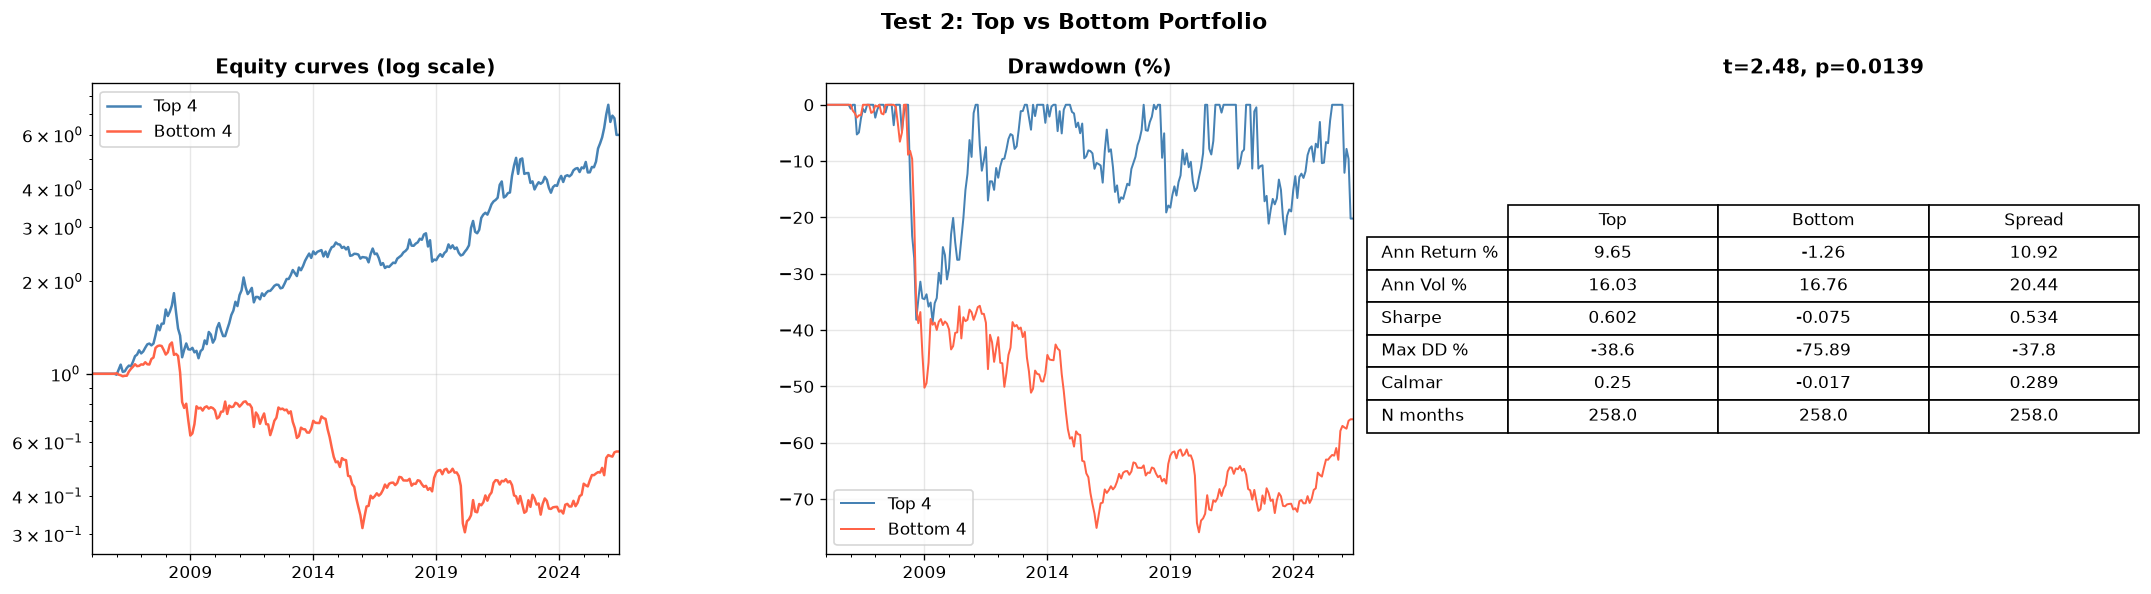

In [3]:
eq_top  = R['t2_top_bottom']['equity_top']
eq_bot  = R['t2_top_bottom']['equity_bot']
spread  = R['t2_top_bottom']['spread']
m_df    = R['t2_top_bottom']['metrics']
t2      = R['t2_top_bottom']['t_stat']
p2      = R['t2_top_bottom']['p_value']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Equity curves
ax = axes[0]
eq_top.plot(ax=ax, label='Top 4', color='steelblue', linewidth=1.5)
eq_bot.plot(ax=ax, label='Bottom 4', color='tomato', linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log scale)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Drawdowns
ax = axes[1]
((eq_top  / eq_top.cummax()  - 1) * 100).plot(ax=ax, label='Top 4',    color='steelblue', linewidth=1.2)
((eq_bot  / eq_bot.cummax()  - 1) * 100).plot(ax=ax, label='Bottom 4', color='tomato',    linewidth=1.2)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Metrics table
ax = axes[2]
ax.axis('off')
tbl = ax.table(cellText=m_df.round(3).values,
               rowLabels=m_df.index, colLabels=m_df.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
ax.set_title(f't={t2:.2f}, p={p2:.4f}', fontweight='bold')

plt.suptitle('Test 2: Top vs Bottom Portfolio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Test 3 — Trend Filter (200DMA)
*Does filtering to price > 200DMA improve risk-adjusted returns?*

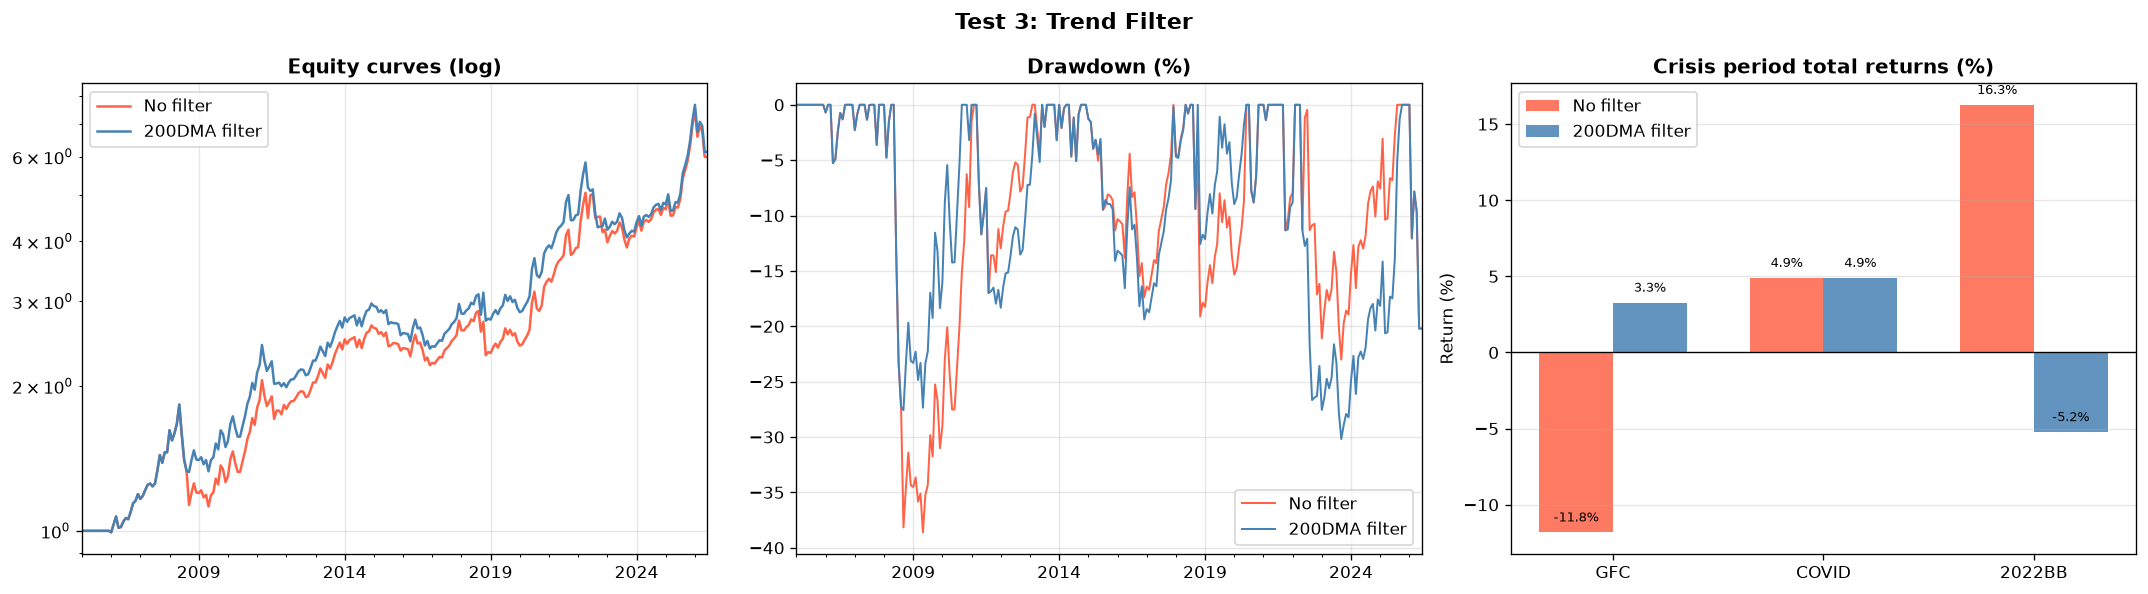


Metrics comparison:
              No filter  200DMA filter
Ann Return %      9.650          9.670
Ann Vol %        16.030         15.460
Sharpe            0.602          0.625
Max DD %        -38.600        -30.180
Calmar            0.250          0.320
N months        258.000        258.000


In [4]:
t3_res    = R['t3_trend']['results']
crisis_df = R['t3_trend']['crisis_returns']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'No filter': 'tomato', '200DMA filter': 'steelblue'}

# Equity curves
ax = axes[0]
for label, res in t3_res.items():
    eq = (1 + res['returns']).cumprod()
    eq.plot(ax=ax, label=label, color=colors[label], linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Drawdowns
ax = axes[1]
for label, res in t3_res.items():
    eq = (1 + res['returns']).cumprod()
    ((eq / eq.cummax() - 1) * 100).plot(ax=ax, label=label, color=colors[label], linewidth=1.2)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Crisis bar chart
ax = axes[2]
x = np.arange(len(crisis_df))
w = 0.35
labels = list(t3_res.keys())
for i, label in enumerate(labels):
    vals = crisis_df[label].values
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=label, color=list(colors.values())[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crisis_df.index)
ax.set_title('Crisis period total returns (%)', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Test 3: Trend Filter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMetrics comparison:')
print(pd.DataFrame({k: v['metrics'] for k, v in t3_res.items()}).to_string())

---
## Test 4 — Portfolio Construction
*Equal weight vs Inverse Vol vs Risk Parity vs HRP*

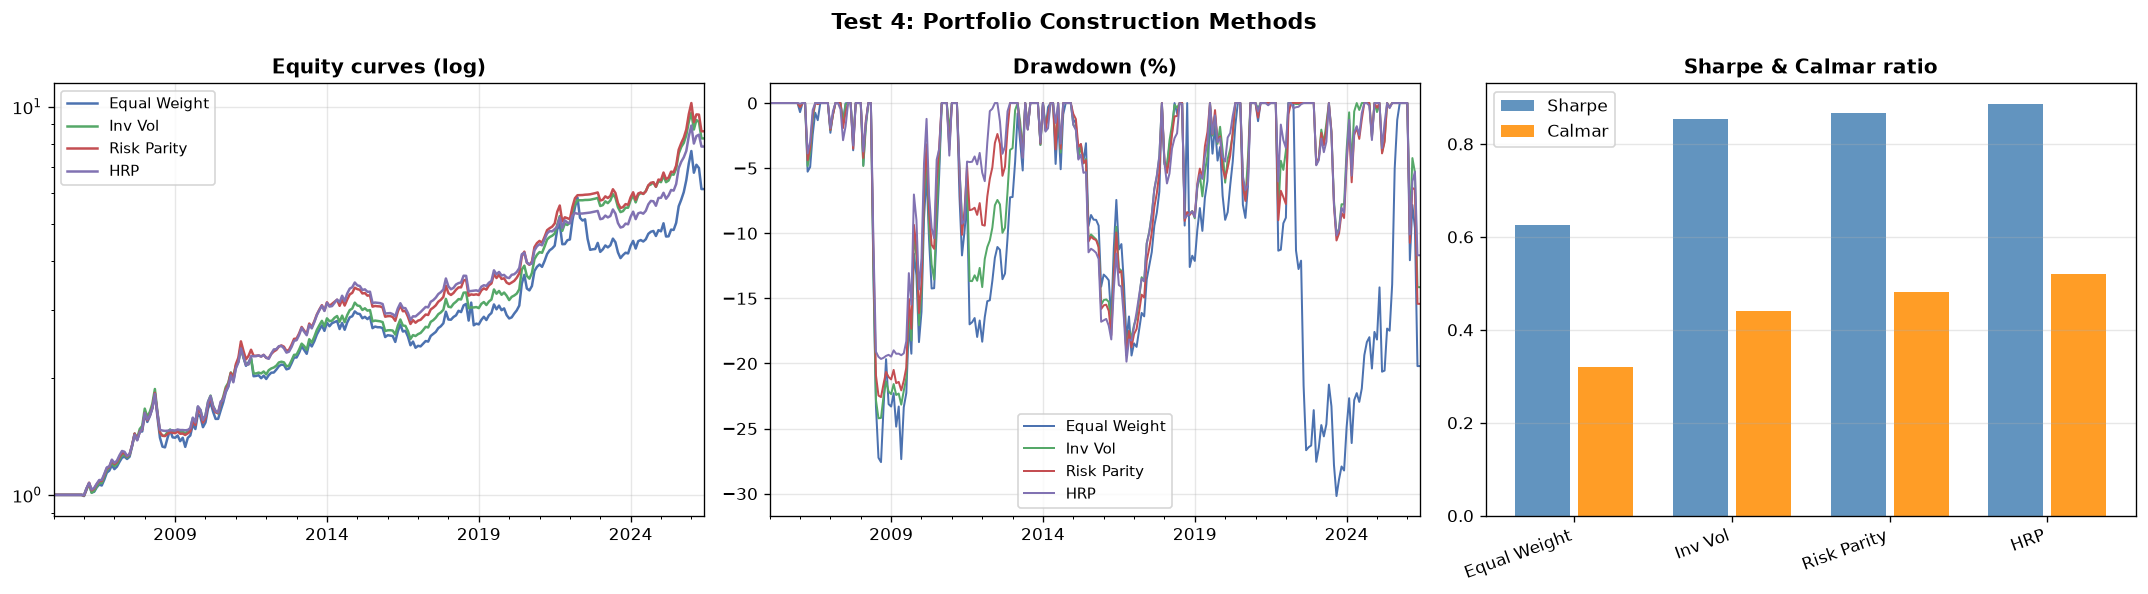


Full metrics:
              Equal Weight  Inv Vol  Risk Parity      HRP
Ann Return %         9.670   10.650       10.850   10.320
Ann Vol %           15.460   12.490       12.510   11.650
Sharpe               0.625    0.853        0.867    0.886
Max DD %           -30.180  -24.210      -22.580  -19.860
Calmar               0.320    0.440        0.481    0.520
N months           258.000  258.000      258.000  258.000


In [5]:
t4 = R['t4_construction']
method_colors = {'equal': '#4C72B0', 'inv_vol': '#55A868', 'risk_parity': '#C44E52', 'hrp': '#8172B2'}
method_labels = {'equal': 'Equal Weight', 'inv_vol': 'Inv Vol', 'risk_parity': 'Risk Parity', 'hrp': 'HRP'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Equity curves
ax = axes[0]
for m, res in t4.items():
    eq = (1 + res['returns']).cumprod()
    eq.plot(ax=ax, label=method_labels[m], color=method_colors[m], linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Drawdowns
ax = axes[1]
for m, res in t4.items():
    eq = (1 + res['returns']).cumprod()
    ((eq / eq.cummax() - 1) * 100).plot(ax=ax, label=method_labels[m], color=method_colors[m], linewidth=1.2)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Metrics bar chart — Sharpe and Calmar
ax = axes[2]
metrics_df = pd.DataFrame({method_labels[m]: v['metrics'] for m, v in t4.items()})
sharpe = metrics_df.loc['Sharpe']
calmar = metrics_df.loc['Calmar']
x = np.arange(len(sharpe))
ax.bar(x - 0.2, sharpe, 0.35, label='Sharpe', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, calmar, 0.35, label='Calmar', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sharpe.index, rotation=20, ha='right')
ax.set_title('Sharpe & Calmar ratio', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Test 4: Portfolio Construction Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFull metrics:')
print(metrics_df.to_string())

---
## Test 5 — Cost Sensitivity
*Does the edge survive realistic transaction costs?*

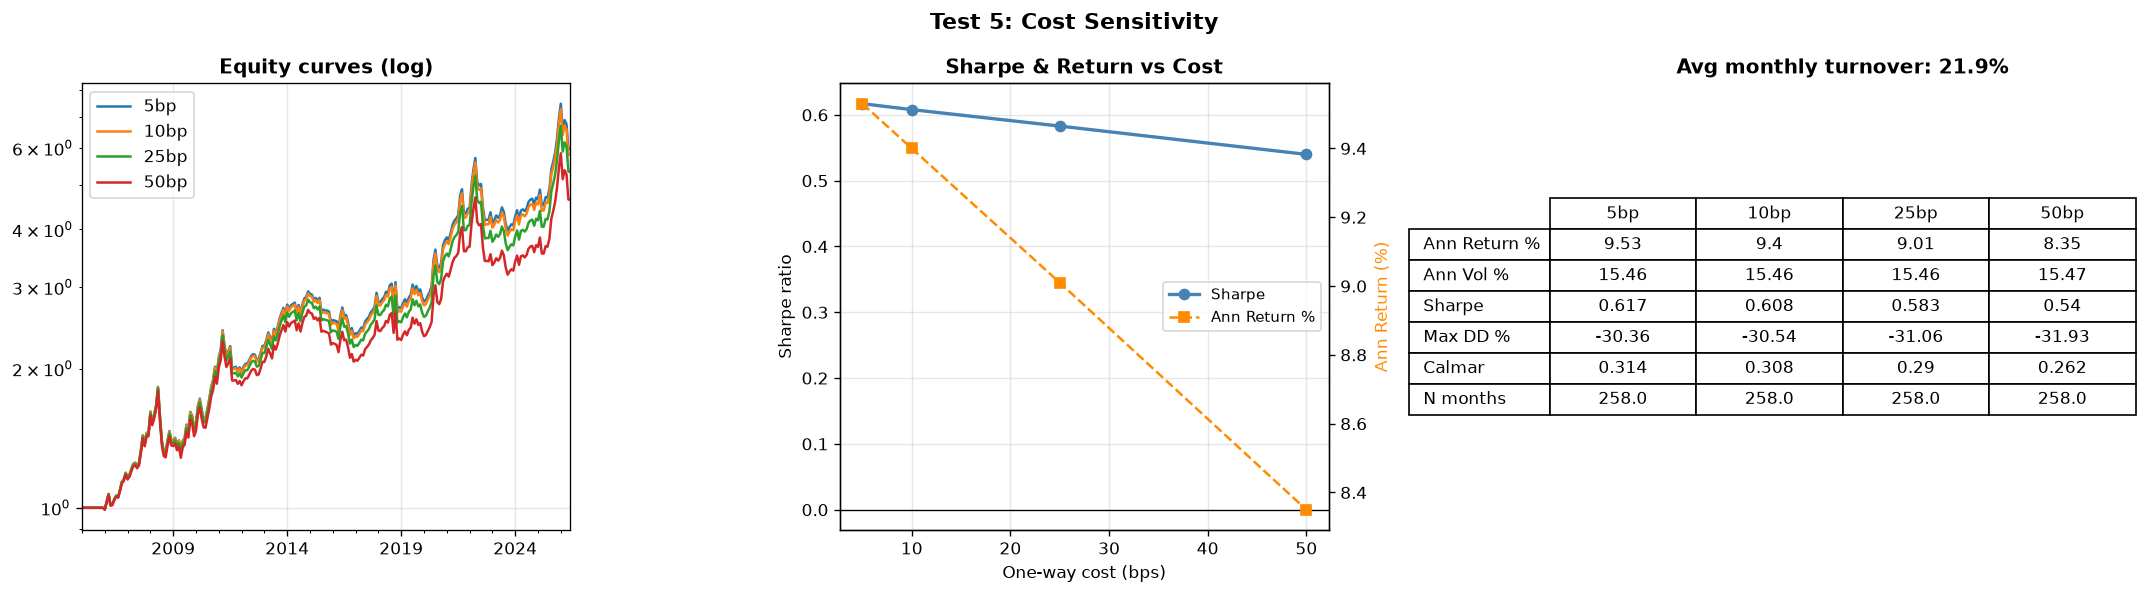


Avg monthly one-way turnover : 21.9%
Annualised two-way turnover  : 525%
Realistic ETF cost ~5-10bp → Sharpe still > 0.6


In [6]:
t5   = R['t5_costs']['results']
avg_to = R['t5_costs']['avg_turnover']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cost_colors = {'5bp': '#1f77b4', '10bp': '#ff7f0e', '25bp': '#2ca02c', '50bp': '#d62728'}

# Equity curves
ax = axes[0]
for label, res in t5.items():
    (1 + res['returns']).cumprod().plot(ax=ax, label=label, color=cost_colors[label], linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Sharpe vs cost
ax = axes[1]
costs_bps = [5, 10, 25, 50]
sharpes   = [t5[f'{c}bp']['metrics']['Sharpe'] for c in costs_bps]
ann_rets  = [t5[f'{c}bp']['metrics']['Ann Return %'] for c in costs_bps]
ax.plot(costs_bps, sharpes, 'o-', color='steelblue', linewidth=2, label='Sharpe')
ax.axhline(0, color='black', linewidth=0.8)
ax2 = ax.twinx()
ax2.plot(costs_bps, ann_rets, 's--', color='darkorange', linewidth=1.5, label='Ann Return %')
ax2.set_ylabel('Ann Return (%)', color='darkorange')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe & Return vs Cost', fontweight='bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
ax.grid(True, alpha=0.3)

# Metrics table
ax = axes[2]
ax.axis('off')
m_df = pd.DataFrame({k: v['metrics'] for k, v in t5.items()})
tbl  = ax.table(cellText=m_df.round(3).values,
                rowLabels=m_df.index, colLabels=m_df.columns,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
ax.set_title(f'Avg monthly turnover: {avg_to*100:.1f}%', fontweight='bold')

plt.suptitle('Test 5: Cost Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAvg monthly one-way turnover : {avg_to*100:.1f}%')
print(f'Annualised two-way turnover  : {avg_to*2*12*100:.0f}%')
print(f'Realistic ETF cost ~5-10bp → Sharpe still > 0.6')

---
## Summary

In [7]:
summary = pd.DataFrame({
    'Test':     ['IC', 'Top vs Bottom', 'Trend Filter', 'Best Construction', 'Cost @ 10bp'],
    'Metric':   [
        f"Mean IC = {R['t1_ic']['mean_ic']:.4f}",
        f"Spread Sharpe = {R['t2_top_bottom']['metrics']['Spread']['Sharpe']:.3f}",
        f"Filter Sharpe = {R['t3_trend']['results']['200DMA filter']['metrics']['Sharpe']:.3f}",
        f"HRP Sharpe = {R['t4_construction']['hrp']['metrics']['Sharpe']:.3f}",
        f"Sharpe = {R['t5_costs']['results']['10bp']['metrics']['Sharpe']:.3f}",
    ],
    'p-value':  [
        f"{R['t1_ic']['p_value']:.4f}",
        f"{R['t2_top_bottom']['p_value']:.4f}",
        '—', '—', '—',
    ],
    'Accept?':  ['YES', 'YES', 'YES (lower DD)', 'HRP wins', 'YES (edge survives)'],
})

print(summary.to_string(index=False))

             Test                Metric p-value             Accept?
               IC      Mean IC = 0.0723  0.0061                 YES
    Top vs Bottom Spread Sharpe = 0.534  0.0139                 YES
     Trend Filter Filter Sharpe = 0.625       —      YES (lower DD)
Best Construction    HRP Sharpe = 0.886       —            HRP wins
      Cost @ 10bp        Sharpe = 0.608       — YES (edge survives)
